# Machine Learning for Business — Week 1
## Classes 1 & 2: The ML Mindset + Core Predictive Models

**BANA 4373 / ECON 4370 — Dr. Fidel González — Sam Houston State University — Spring 2026**

---

### About this notebook

We are using **calibrated synthetic data** — a telecom customer dataset generated from a known data-generating process. The TRUE churn probabilities are planted into the simulation so you can evaluate whether your model recovers the right signals.

| Planted parameter | Value | Rationale |
|---|---|---|
| Base churn rate | 15% | Typical mid-market telecom |
| Monthly charges effect | Strong positive | Higher bill → higher churn risk |
| Tenure effect | Strong negative | Longer customers → more loyal |
| Month-to-month contract | Large positive | Flexible contract → easy to leave |
| Support calls effect | Moderate positive | Frustration signal |

**Why synthetic?** In real data you never know which features truly drive churn. Today we do. The homework uses real telecom data.

---

### Two-class structure

| Class | Focus | Goal |
|---|---|---|
| **Class 1 — The ML Mindset** | ML vocabulary, workflow, train/test split, overfitting | Internalize the prediction vs. causation distinction; build your first model |
| **Class 2 — Core Models** | OLS baseline, Ridge/Lasso, Decision Tree, Random Forest, Gradient Boosting | Compare model families on the churn problem; practice reading feature importance |

---

> **Folder structure reminder:** `ROOT/data_raw/` → `data_clean/` → `exports/`
>
> All outputs (charts, model summaries) go to `exports/` before submission.

**Student Name:** ___________________________

Make sure you run all cells and answer all questions before submitting.

---
## ⭐ Write Your Prior — Class 1

> **Before writing any code, answer these on paper (or in the cell below). You will revisit your answers at the end of Class 1.**

1. A model achieves **99% accuracy on training data** and **62% accuracy on test data**. What is your diagnosis? What would you do?

2. A bank wants to predict whether a loan will default. List **three features** you think would be useful. List **one feature** that might cause ethical problems.

3. If you use the same data to *train* and *evaluate* a model, will your error estimate be too high, too low, or correct? Explain in one sentence.

**Your answers (write before running any code):**

1. 

2. 

3. 

---
## 0) Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, confusion_matrix
)

# Plot style
NAVY   = '#001F54'
TEAL   = '#006D77'
GOLD   = '#C5A000'
RED    = '#C0392B'
GRAY   = '#7F8C8D'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

import os
os.makedirs('data_raw',  exist_ok=True)
os.makedirs('data_clean', exist_ok=True)
os.makedirs('exports',   exist_ok=True)

SEED = 42
np.random.seed(SEED)
print('Setup complete.')

Setup complete.


---
## Part 1 — Simulate the Telecom Dataset

We generate 4,000 customers with a **known data-generating process**. This means we can audit our models against the truth.

In [4]:
np.random.seed(SEED)
N = 4000

# --- Feature simulation ---
tenure          = np.random.gamma(shape=4, scale=8, size=N).clip(1, 72)     # months, 1–72
monthly_charges = np.random.normal(65, 20, N).clip(20, 120)                  # dollars
contract_type   = np.random.choice(['Month-to-Month', 'One Year', 'Two Year'],
                                   p=[0.55, 0.25, 0.20], size=N)
support_calls   = np.random.poisson(lam=1.5, size=N).clip(0, 10)
data_usage_gb   = np.random.exponential(scale=8, size=N).clip(0.5, 50)
senior_citizen  = np.random.binomial(1, 0.16, N)

# --- Encode contract for DGP ---
contract_risk = np.where(contract_type == 'Month-to-Month', 1.0,
               np.where(contract_type == 'One Year', 0.3, 0.0))

# --- TRUE linear predictor (logistic DGP) ---
# Planted effects (log-odds units)
log_odds = (
    -2.5                          # intercept (sets base rate ~15%)
    + 0.035 * monthly_charges     # higher bill → more likely to churn
    - 0.060 * tenure              # longer tenure → more loyal
    + 1.40  * contract_risk       # month-to-month is risky
    + 0.25  * support_calls       # frustration signal
    - 0.015 * data_usage_gb       # heavy data users stay (stickiness)
    + 0.30  * senior_citizen      # slight effect
)
TRUE_PROB = 1 / (1 + np.exp(-log_odds))
churn = np.random.binomial(1, TRUE_PROB)

# --- Build DataFrame ---
df = pd.DataFrame({
    'tenure':           tenure.round(0).astype(int),
    'monthly_charges':  monthly_charges.round(2),
    'contract_type':    contract_type,
    'support_calls':    support_calls,
    'data_usage_gb':    data_usage_gb.round(2),
    'senior_citizen':   senior_citizen,
    'TRUE_PROB':        TRUE_PROB.round(4),  # ground truth — for auditing only
    'churn':            churn
})

df.to_csv('data_raw/telecom_synthetic.csv', index=False)
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Overall churn rate: {df.churn.mean():.1%}')
df.head()

Dataset: 4,000 rows × 8 columns
Overall churn rate: 33.0%


,tenure,monthly_charges,contract_type,support_calls,data_usage_gb,senior_citizen,TRUE_PROB,churn
0,38,62.68,Month-to-Month,3,18.30,0,0.3345,0
1,27,67.48,Month-to-Month,1,1.97,0,0.4617,0
2,26,102.94,Month-to-Month,2,4.44,0,0.7994,1
3,26,57.21,Month-to-Month,0,28.58,0,0.2535,0
4,61,78.74,Month-to-Month,3,14.02,0,0.1898,0


---
## Part 2 — Exploratory Data Analysis

Before any model: **look at the data**.

In [6]:
print('=== Descriptive Statistics ===')
print(df.drop(columns=['TRUE_PROB']).describe().round(2))

=== Descriptive Statistics ===
        tenure  monthly_charges  support_calls  data_usage_gb  senior_citizen  \
count  4000.00          4000.00        4000.00        4000.00         4000.00   
mean     31.92            64.97           1.55           7.95            0.16   
std      15.25            19.86           1.24           7.85            0.36   
min       2.00            20.00           0.00           0.50            0.00   
25%      21.00            51.15           1.00           2.27            0.00   
50%      30.00            64.65           1.00           5.51            0.00   
75%      41.00            78.39           2.00          11.12            0.00   
max      72.00           120.00           8.00          50.00            1.00   

         churn  
count  4000.00  
mean      0.33  
std       0.47  
min       0.00  
25%       0.00  
50%       0.00  
75%       1.00  
max       1.00  


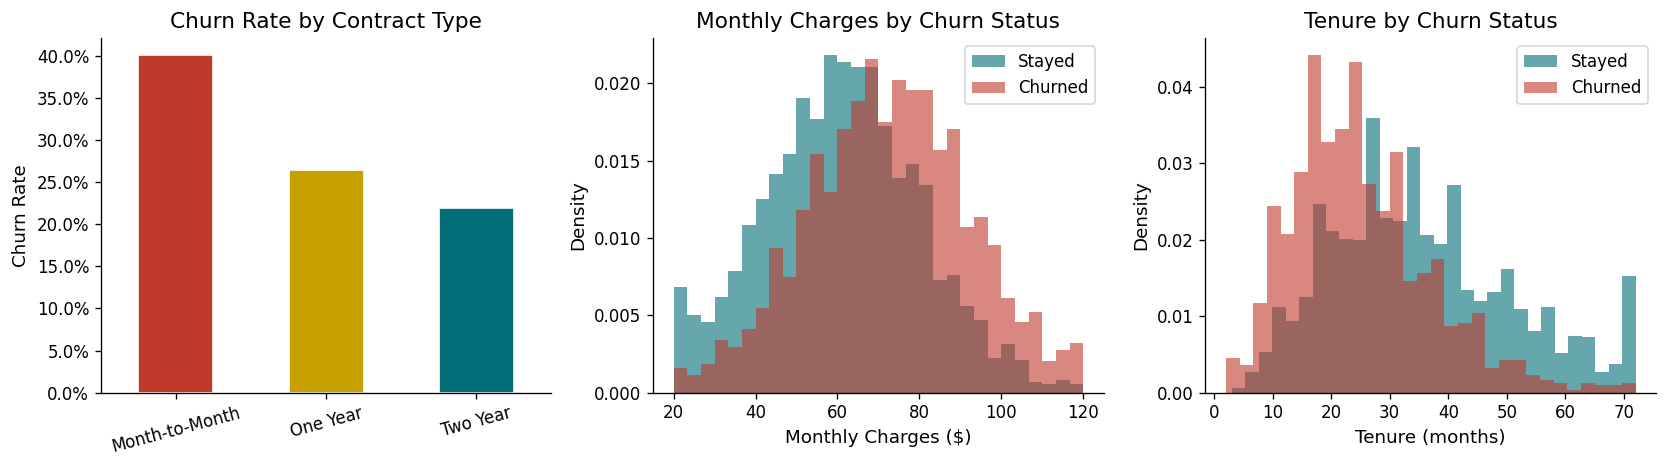

Saved → exports/churn_eda.png


In [8]:
# Churn rate by contract type
churn_by_contract = df.groupby('contract_type')['churn'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Churn rate by contract
churn_by_contract.plot(kind='bar', ax=axes[0], color=[RED, GOLD, TEAL], edgecolor='white')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].tick_params(axis='x', rotation=15)

# Panel 2: Monthly charges distribution by churn
for val, color, label in zip([0, 1], [TEAL, RED], ['Stayed', 'Churned']):
    axes[1].hist(df.loc[df.churn==val, 'monthly_charges'], bins=30,
                 alpha=0.6, color=color, label=label, density=True)
axes[1].set_title('Monthly Charges by Churn Status')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

# Panel 3: Tenure distribution by churn
for val, color, label in zip([0, 1], [TEAL, RED], ['Stayed', 'Churned']):
    axes[2].hist(df.loc[df.churn==val, 'tenure'], bins=30,
                 alpha=0.6, color=color, label=label, density=True)
axes[2].set_title('Tenure by Churn Status')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig('exports/churn_eda.png', bbox_inches='tight')
plt.show()
print('Saved → exports/churn_eda.png')

**💬 Interpretation (fill in):**

Looking at the three panels:
- The contract type with the highest churn rate is: ___
- Churned customers tend to have (higher/lower) monthly charges than those who stay: ___
- Churned customers tend to have (longer/shorter) tenure: ___

Do these patterns align with the planted DGP? Why or why not?

---
## Part 3 — Feature Engineering and Train/Test Split

> **Core rule: split before you touch the data.**
> Nothing from the test set may influence your preprocessing.

In [10]:
# Step 1: Encode categorical features
df_model = df.drop(columns=['TRUE_PROB']).copy()   # never feed ground truth into a model
df_model = pd.get_dummies(df_model, columns=['contract_type'], drop_first=False)

# Rename dummy columns for readability
df_model.rename(columns={
    'contract_type_Month-to-Month': 'contract_monthly',
    'contract_type_One Year':       'contract_one_year',
    'contract_type_Two Year':       'contract_two_year'
}, inplace=True)

FEATURES = ['tenure', 'monthly_charges', 'support_calls',
            'data_usage_gb', 'senior_citizen',
            'contract_monthly', 'contract_one_year', 'contract_two_year']
TARGET   = 'churn'

X = df_model[FEATURES]
y = df_model[TARGET]

# Step 2: Train/test split — 80/20, stratified
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} rows  |  churn rate: {y_train.mean():.1%}')
print(f'Test set:      {X_test.shape[0]:,} rows  |  churn rate: {y_test.mean():.1%}')
print(f'\nFeatures used: {FEATURES}')

Training set:  3,200 rows  |  churn rate: 33.0%
Test set:      800 rows  |  churn rate: 33.0%

Features used: ['tenure', 'monthly_charges', 'support_calls', 'data_usage_gb', 'senior_citizen', 'contract_monthly', 'contract_one_year', 'contract_two_year']


In [12]:
# Step 3: Standardize AFTER splitting (fit scaler on train only)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)       # transform only — do not re-fit

print('Scaling done. Mean of training features (should be ~0):')
print(pd.Series(X_train_s.mean(axis=0).round(3), index=FEATURES))

Scaling done. Mean of training features (should be ~0):
tenure               0.0
monthly_charges     -0.0
support_calls        0.0
data_usage_gb        0.0
senior_citizen       0.0
contract_monthly    -0.0
contract_one_year   -0.0
contract_two_year    0.0
dtype: float64


**⚠️ Why do we fit the scaler on training data only?**

> **Your answer:** 

---
## Part 4 — Overfitting Demo: Bias-Variance in Action

Before fitting real models, let's *see* overfitting with a Decision Tree as we vary max depth.

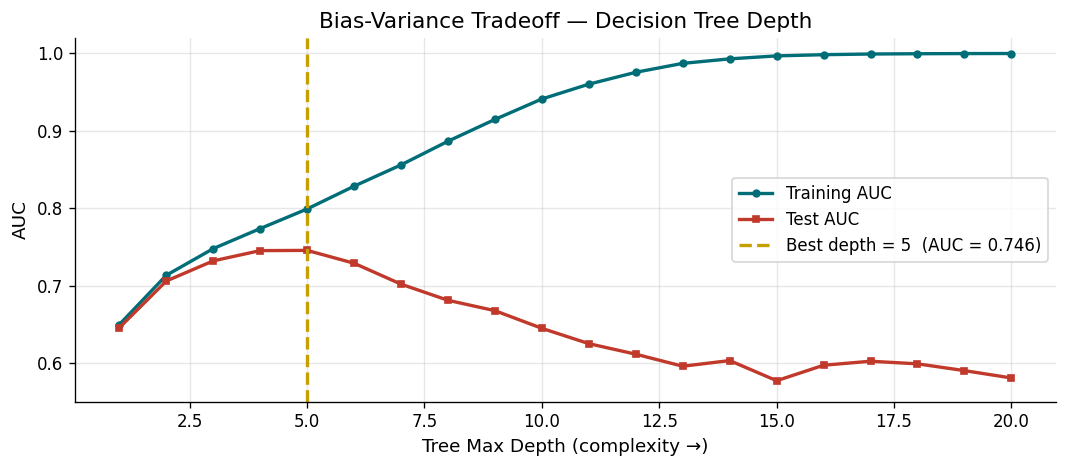

Best depth on test set: 5  (Test AUC = 0.746)


In [14]:
depths  = list(range(1, 21))
train_auc = []
test_auc  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt.fit(X_train, y_train)
    train_auc.append(roc_auc_score(y_train, dt.predict_proba(X_train)[:,1]))
    test_auc.append( roc_auc_score(y_test,  dt.predict_proba(X_test)[:,1]))

# Find sweet spot
best_depth = depths[np.argmax(test_auc)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_auc, color=TEAL, lw=2, marker='o', markersize=4, label='Training AUC')
ax.plot(depths, test_auc,  color=RED,  lw=2, marker='s', markersize=4, label='Test AUC')
ax.axvline(best_depth, color=GOLD, lw=2, ls='--',
           label=f'Best depth = {best_depth}  (AUC = {max(test_auc):.3f})')
ax.set_xlabel('Tree Max Depth (complexity →)')
ax.set_ylabel('AUC')
ax.set_title('Bias-Variance Tradeoff — Decision Tree Depth')
ax.legend()
ax.set_ylim(0.55, 1.02)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('exports/bias_variance_tradeoff.png', bbox_inches='tight')
plt.show()
print(f'Best depth on test set: {best_depth}  (Test AUC = {max(test_auc):.3f})')

**💬 Interpretation (fill in):**

1. At depth = 1, both train and test AUC are low. This is called ___.
2. As depth increases beyond ~___, training AUC keeps rising but test AUC falls. This is called ___.
3. The best depth is ___, which represents the sweet spot between bias and variance.
4. Revisit your Write Your Prior answer #1. Were you right?

---
## Part 5 — K-Fold Cross-Validation

K-Fold gives a stable performance estimate by rotating which fold serves as validation.

In [16]:
dt_cv = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(dt_cv, X_train, y_train,
                            cv=kf, scoring='roc_auc')

print('5-Fold Cross-Validation AUC (training set only):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean:  {cv_scores.mean():.4f}')
print(f'  Std:   {cv_scores.std():.4f}')
print(f'\nFinal Test AUC (held-out): {test_auc[best_depth-1]:.4f}')

5-Fold Cross-Validation AUC (training set only):
  Fold 1: 0.7427
  Fold 2: 0.7573
  Fold 3: 0.7087
  Fold 4: 0.7384
  Fold 5: 0.7508

  Mean:  0.7396
  Std:   0.0168

Final Test AUC (held-out): 0.7455


**💬 Interpretation:** The CV mean AUC and the held-out test AUC are (similar/very different). What does this tell you about whether the model is overfit? 

---
---
## ⭐ Write Your Prior — Class 2

> **Before running any model comparison code, write your predictions:**

1. You are building a churn model. You have these features: customer name, account number, monthly bill, contract type, number of support calls, and zip code. **Which features would you include?** Justify each.

2. Without running any code: do you expect Random Forest or Logistic Regression to perform better on churn prediction? Write a one-sentence reason.

3. A model correctly classifies 90% of customers. The churn rate is 5%. Is 90% accuracy impressive? (Hint: what happens if the model predicts 'Stay' for everyone?)

**Your answers (write before running any Class 2 code):**

1. 

2. 

3. 

---
## Part 6 — OLS/Logistic Baseline

> **Rule:** Every ML project starts with a simple baseline. All fancier models must beat it.

In [ ]:
# Logistic Regression baseline
logit = LogisticRegression(max_iter=1000, random_state=SEED)
logit.fit(X_train_s, y_train)

logit_train_auc = roc_auc_score(y_train, logit.predict_proba(X_train_s)[:,1])
logit_test_auc  = roc_auc_score(y_test,  logit.predict_proba(X_test_s)[:,1])
logit_test_acc  = accuracy_score(y_test,  logit.predict(X_test_s))

print('=== Logistic Regression Baseline ===')
print(f'Train AUC:   {logit_train_auc:.4f}')
print(f'Test AUC:    {logit_test_auc:.4f}    ← target to beat')
print(f'Test Accuracy: {logit_test_acc:.1%}')

# Coefficient table
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': logit.coef_[0].round(4)
}).sort_values('Coefficient', key=abs, ascending=False)

print('\nCoefficients (standardized features → comparable magnitude):')
print(coef_df.to_string(index=False))

**💬 Interpretation:**

1. Which feature has the largest positive effect on churn probability? Does this match the planted DGP?
2. Which feature has the largest negative effect (protective factor)?
3. Can we interpret these coefficients causally — e.g., 'raising monthly charges by $1 causes churn to rise by X%'? Why or why not?

---
## Part 7 — Regularized Regression: Ridge and Lasso

In [ ]:
# Ridge via LogisticRegression with L2 penalty
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=SEED))
])

# Lasso via LogisticRegression with L1 penalty
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(penalty='l1', C=0.1, solver='saga', max_iter=2000, random_state=SEED))
])

ridge_pipe.fit(X_train, y_train)
lasso_pipe.fit(X_train, y_train)

ridge_auc = roc_auc_score(y_test, ridge_pipe.predict_proba(X_test)[:,1])
lasso_auc = roc_auc_score(y_test, lasso_pipe.predict_proba(X_test)[:,1])

# Show Lasso sparsity
lasso_coefs = lasso_pipe.named_steps['model'].coef_[0]
nonzero = np.sum(lasso_coefs != 0)

print(f'Ridge Test AUC:  {ridge_auc:.4f}')
print(f'Lasso Test AUC:  {lasso_auc:.4f}')
print(f'\nLasso kept {nonzero}/{len(FEATURES)} features (drove {len(FEATURES)-nonzero} to exactly zero)')
print('\nLasso coefficients:')
for f, c in zip(FEATURES, lasso_coefs):
    status = '← ZEROED OUT' if c == 0 else ''
    print(f'  {f:25s}  {c:+.4f}  {status}')

**💬 Lasso Feature Selection:**

Which features did Lasso zero out? Do you agree with those choices based on the planted DGP? What does this tell you about those features' predictive value?

---
## Part 8 — Decision Tree

In [ ]:
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
dt_final.fit(X_train, y_train)
dt_auc = roc_auc_score(y_test, dt_final.predict_proba(X_test)[:,1])

print(f'Decision Tree (depth={best_depth}) Test AUC: {dt_auc:.4f}')
print('\nTop 5 levels of the decision tree:')
print(export_text(dt_final, feature_names=FEATURES, max_depth=3))

**💬 Tree Interpretation:** What is the first split? What feature does the tree consider most important at the root? Does this match your prior and the planted DGP?

---
## Part 9 — Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                            random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print(f'Random Forest Test AUC: {rf_auc:.4f}')

# Feature importance
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [RED if f in ['contract_monthly', 'monthly_charges', 'support_calls']
          else TEAL for f in fi.index]
fi.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.set_xlabel('Importance (mean decrease in impurity)')
plt.tight_layout()
plt.savefig('exports/rf_feature_importance.png', bbox_inches='tight')
plt.show()

**💬 Feature Importance vs. Causal Effects:**

The Random Forest feature importance tells us which features are most *predictive*. Does this mean those features *cause* churn? Explain the distinction in 2–3 sentences.

---
## Part 10 — Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)
gb.fit(X_train, y_train)
gb_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])

# Track training curve
train_scores_gb = []
test_scores_gb  = []
for yhat_train, yhat_test in zip(
    gb.staged_predict_proba(X_train),
    gb.staged_predict_proba(X_test)
):
    train_scores_gb.append(roc_auc_score(y_train, yhat_train[:,1]))
    test_scores_gb.append( roc_auc_score(y_test,  yhat_test[:,1]))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_scores_gb, color=TEAL, lw=1.5, label='Train AUC')
ax.plot(test_scores_gb,  color=RED,  lw=1.5, label='Test AUC')
ax.axvline(np.argmax(test_scores_gb), color=GOLD, ls='--', lw=1.5,
           label=f'Best iter = {np.argmax(test_scores_gb)}')
ax.set_xlabel('Boosting Iteration')
ax.set_ylabel('AUC')
ax.set_title('Gradient Boosting Learning Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('exports/gb_learning_curve.png', bbox_inches='tight')
plt.show()

print(f'Gradient Boosting Test AUC: {gb_auc:.4f}')

**💬 Learning Curve Interpretation:**

At what iteration do train and test AUC start to diverge noticeably? What does that tell you? If we were using early stopping, where would we stop?

---
## Part 11 — Model Comparison

> **Write your prior before running this cell:** Which model do you expect to win? By how much?

**Your prediction:** 

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression (baseline)',
        'Ridge (L2)',
        'Lasso (L1)',
        f'Decision Tree (depth={best_depth})',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Test AUC': [
        logit_test_auc, ridge_auc, lasso_auc,
        dt_auc, rf_auc, gb_auc
    ]
}).sort_values('Test AUC', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [NAVY if 'Boosting' in m else
              TEAL if 'Forest' in m else
              GOLD if 'Tree' in m else
              GRAY for m in results['Model']]
bars = ax.barh(results['Model'], results['Test AUC'],
               color=bar_colors, edgecolor='white')
ax.axvline(0.5, color=RED, ls='--', lw=1, label='Random baseline (AUC=0.5)')
for bar, auc in zip(bars, results['Test AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f}', va='center', fontsize=9)
ax.set_xlim(0.45, 1.05)
ax.set_xlabel('Test AUC (held-out set)')
ax.set_title('Model Comparison — Customer Churn Prediction', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('exports/model_comparison.png', bbox_inches='tight')
plt.show()

print(results.to_string(index=False))

**💬 Reflection (fill in):**

1. Was your prediction correct? Which model won?
2. The best model beats the logistic baseline by ___ AUC points. Is that meaningful for a business decision?
3. If a manager told you 'we need to know *why* customers churn, not just *who* will churn' — which model would you choose, and why?

---
## Part 12 — Break the Estimator: Data Leakage Demo

What if we made the common mistake of scaling *before* splitting?

In [ ]:
# ❌ WRONG: fit scaler on ALL data (leakage)
scaler_leak = StandardScaler()
X_scaled_leak = scaler_leak.fit_transform(X)          # uses test set in the fit!

X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_scaled_leak, y, test_size=0.20, random_state=SEED, stratify=y
)

logit_leak = LogisticRegression(max_iter=1000, random_state=SEED)
logit_leak.fit(X_train_leak, y_train_leak)
auc_leak = roc_auc_score(y_test_leak, logit_leak.predict_proba(X_test_leak)[:,1])

# ✅ CORRECT: scale after split (our earlier approach)
auc_correct = logit_test_auc

print('=== Data Leakage Comparison ===')
print(f'❌ Leaked (scale before split):  AUC = {auc_leak:.4f}')
print(f'✅ Correct (scale after split):  AUC = {auc_correct:.4f}')
print(f'\nDifference: {auc_leak - auc_correct:.4f}')
print('\nNote: With only feature scaling the leakage here is small.')
print('With target-leaking features (future data), the gap can be 0.3+ AUC!')

**💬 Why is data leakage dangerous in production?**

Explain in 2 sentences why an inflated AUC from leakage leads to business losses when the model is deployed.

---
## Part 13 — Business Impact Calculation

> **Context (from slides):** 10,000 customers, 15% monthly churn, $300 loss per churner, $30 retention offer cost.

In [ ]:
# Simulate business impact on held-out test set
N_CUSTOMERS   = 10_000
LOSS_PER_CHURN  = 300
OFFER_COST      = 30
CHURN_RATE      = 0.15

# Recall of our best model (Gradient Boosting) at 0.5 threshold
from sklearn.metrics import recall_score, precision_score

gb_preds   = gb.predict(X_test)
gb_recall  = recall_score(y_test, gb_preds)
gb_prec    = precision_score(y_test, gb_preds)

# Business math
true_churners   = N_CUSTOMERS * CHURN_RATE          # ~1,500
caught          = true_churners * gb_recall          # churners we flag
offers_sent     = caught / gb_prec                   # all customers flagged
saved_revenue   = caught * LOSS_PER_CHURN            # assume 100% retention if flagged
offer_spend     = offers_sent * OFFER_COST
net_benefit     = saved_revenue - offer_spend

print('=== Business Impact Analysis ===')
print(f'Monthly churners (true):     {true_churners:,.0f}')
print(f'Model recall:                {gb_recall:.1%}')
print(f'Model precision:             {gb_prec:.1%}')
print(f'Churners caught:             {caught:,.0f}')
print(f'Retention offers sent:       {offers_sent:,.0f}')
print(f'Revenue saved:              ${saved_revenue:>10,.0f}')
print(f'Offer cost:                -${offer_spend:>10,.0f}')
print(f'Net monthly benefit:        ${net_benefit:>10,.0f}')
print(f'\nAnnual benefit estimate:    ${net_benefit*12:>10,.0f}')

**💬 Your Turn:** Recalculate assuming the model precision drops from the current value to **40%** (more false alarms). Does the net benefit increase or decrease? Why does precision matter here?

In [ ]:
# TODO: repeat the business math with precision = 0.40
# Replace the precision value and re-run

assumed_precision = 0.40   # <- change this

# Your code here:


---
## Part 14 — Revisit Your Priors

> Look back at your Write Your Prior answers from Class 1 and Class 2.

**Class 1 Prior Revisit:**

- Q1 (99% train, 62% test): Were you right? What is the term for this?
- Q3 (same data to train & evaluate): Was your answer correct? What happens when you do this?

**Class 2 Prior Revisit:**

- Q2 (RF vs. Logistic): Which actually won?
- Q3 (90% accuracy with 5% churn): Walk through the math. What accuracy would 'predict everyone stays' achieve?

---
## Submission Checklist

Before submitting to Blackboard, verify:

- [ ] Student name is filled in at the top
- [ ] All cells have been run (no empty output cells)
- [ ] All Write Your Prior cells are filled in
- [ ] All Interpretation cells are filled in
- [ ] All 'Your Turn' exercises are attempted
- [ ] `exports/` folder contains: `churn_eda.png`, `bias_variance_tradeoff.png`, `rf_feature_importance.png`, `gb_learning_curve.png`, `model_comparison.png`
- [ ] Notebook is submitted as `.ipynb` (not PDF)

**Point allocation:**

| Section | Points |
|---|---|
| Write Your Prior — Class 1 (attempted before running) | 10 |
| Write Your Prior — Class 2 (attempted before running) | 10 |
| Interpretation cells (6 × 5 pts each) | 30 |
| Business impact Your Turn | 15 |
| Prior Revisit reflection | 15 |
| Code runs without errors, exports saved | 20 |
| **Total** | **100** |